# Application 1 — Diabetes Prediction
### Intelligent System Development — Assignment 02 (PTIT)

Pipeline: **Data → Understand → Clean → Represent → Learn → Evaluate → Persist → Deploy**


## 1. Problem definition

This is a **binary classification** task under supervised learning.

X = patient features (8-dimensional clinical/demographic vector)
y = diabetes class, y ∈ {0, 1} — 0 = no diabetes, 1 = diabetes

Goal: predict whether a patient is likely to have diabetes based on demographic and
clinical measurements, to support early screening.

## 2. Dataset source

- **Kaggle dataset name:** Diabetes prediction dataset
- **Kaggle URL:** https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset
- **Rows:** 100,000
- **Features:** 8 input features + 1 target (`diabetes`)
- **Feature names:** gender, age, hypertension, heart_disease, smoking_history, bmi, HbA1c_level, blood_glucose_level
- **Target variable:** diabetes (0/1)

## 3. Dataset loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, joblib, os, time
warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df_raw = pd.read_csv("../data/diabetes.csv")
df_raw.shape

(100000, 9)

## 4. Dataset inspection

In [2]:
df_raw.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [4]:
df_raw.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


## 5. Data-quality analysis

Summary of columns by type:
- **Numerical:** age, bmi, HbA1c_level, blood_glucose_level
- **Binary (numeric-coded categorical):** hypertension, heart_disease
- **Categorical (text):** gender, smoking_history
- **Target:** diabetes

In [5]:
numeric_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level", "hypertension", "heart_disease"]
categorical_cols = ["gender", "smoking_history"]
TARGET_COL = "diabetes"
feature_cols = numeric_cols + categorical_cols
print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)
print("Target:", TARGET_COL)

Numeric: ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'hypertension', 'heart_disease']
Categorical: ['gender', 'smoking_history']
Target: diabetes


## 6. Missing-value analysis

In [6]:
df_raw.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

**Observation:** no missing values in any column — the dataset is already complete, so no imputation of missing cells is required at the raw-data stage (a `SimpleImputer` is still included in the pipeline as a safety net for any future/unseen data).

## 7. Duplicate analysis

In [7]:
n_dup = df_raw.duplicated().sum()
print("Duplicated rows:", n_dup)

Duplicated rows: 3854


**Observation:** 3,854 exact duplicate rows were found (≈3.9% of the dataset). These likely come from repeated data-collection entries and would bias the model if kept (the same patient profile would be seen multiple times, inflating its influence on the learned decision boundary and on evaluation metrics). They are removed in Part III.

## 8. Invalid-value analysis

In [8]:
invalid_age = (df_raw["age"] <= 0).sum()
invalid_bmi = ((df_raw["bmi"] < 10) | (df_raw["bmi"] > 80)).sum()
print("Invalid age (<=0):", invalid_age)
print("Invalid BMI (<10 or >80, implausible for a living patient):", invalid_bmi)

Invalid age (<=0): 0
Invalid BMI (<10 or >80, implausible for a living patient): 9


## 9. Outlier analysis

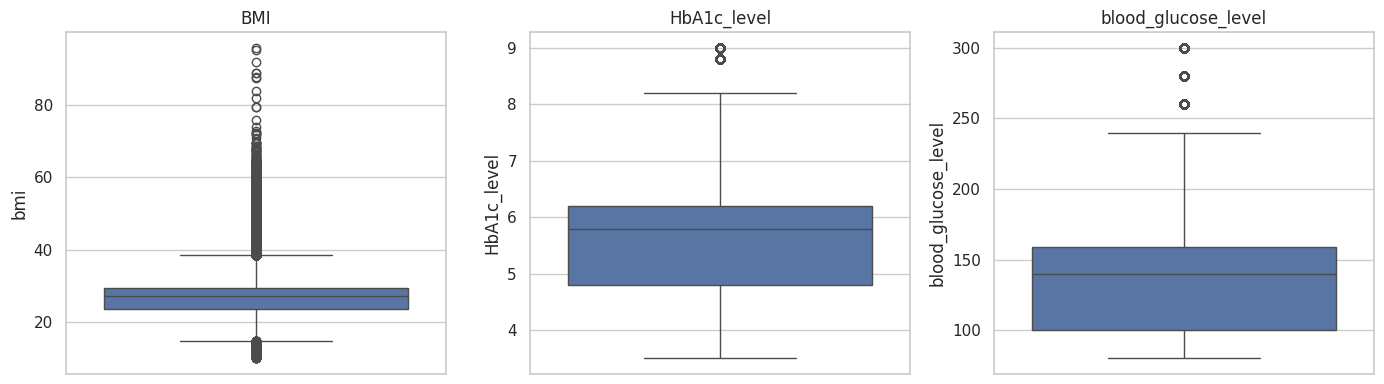

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.boxplot(y=df_raw["bmi"], ax=axes[0]); axes[0].set_title("BMI")
sns.boxplot(y=df_raw["HbA1c_level"], ax=axes[1]); axes[1].set_title("HbA1c_level")
sns.boxplot(y=df_raw["blood_glucose_level"], ax=axes[2]); axes[2].set_title("blood_glucose_level")
plt.tight_layout(); plt.show()

**Observation:** BMI shows a small number of high-value outliers (>60) that are clinically implausible and are removed together with the invalid-value filter above. HbA1c and blood glucose have wide but clinically plausible ranges (these elevated values are precisely what signals diabetes), so they are **kept** rather than removed — filtering them out would remove exactly the signal the model needs to learn.

## Part III — Data Cleaning

Applied operations, and **why** each is performed:
1. **Remove duplicates** — prevents the same patient record from being over-weighted during training/evaluation.
2. **Remove invalid BMI values** (<10 or >80) — physiologically impossible values that would distort the scaler's mean/std.
3. **Keep NaN-imputer in the pipeline** even though no NaNs exist today, for robustness against unseen/future data (avoids the pipeline breaking on a single missing cell in production).

In [10]:
df = df_raw.drop_duplicates().reset_index(drop=True)
before, after = df_raw.shape[0], df.shape[0]
df = df[(df["age"] > 0) & (df["bmi"] >= 10) & (df["bmi"] <= 80)].reset_index(drop=True)
print(f"Rows: {before} -> after dedup -> {after} -> after invalid-value removal -> {df.shape[0]}")
df[TARGET_COL].value_counts(normalize=True)

Rows: 100000 -> after dedup -> 96146 -> after invalid-value removal -> 96137


diabetes
0    0.911803
1    0.088197
Name: proportion, dtype: float64

**Class imbalance:** only ~8.8% of patients are positive for diabetes. This motivates evaluating with Precision/Recall/F1/ROC-AUC rather than Accuracy alone, and using `stratify=y` when splitting.

## 10. Exploratory Data Analysis

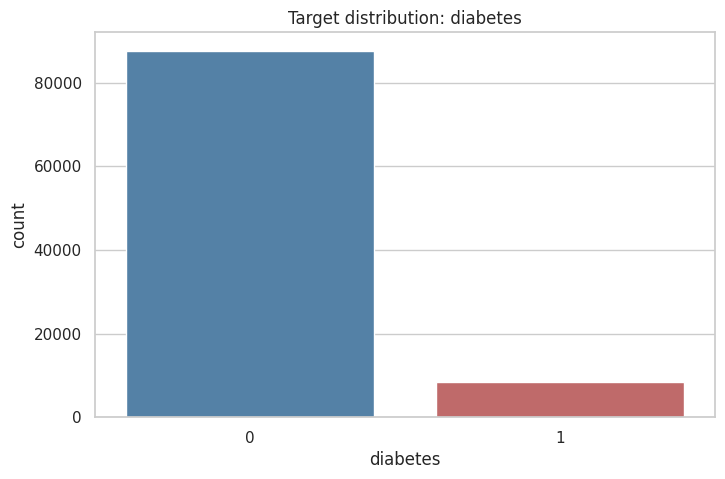

In [11]:
plt.figure()
sns.countplot(x=TARGET_COL, data=df, palette=["steelblue","indianred"])
plt.title("Target distribution: diabetes")
plt.show()

**Observation:** strong class imbalance (~91%/9%). **Interpretation:** a naive always-predict-0 classifier would already score ~91% accuracy. **ML implication:** Accuracy alone is misleading; Recall and ROC-AUC must be reported.

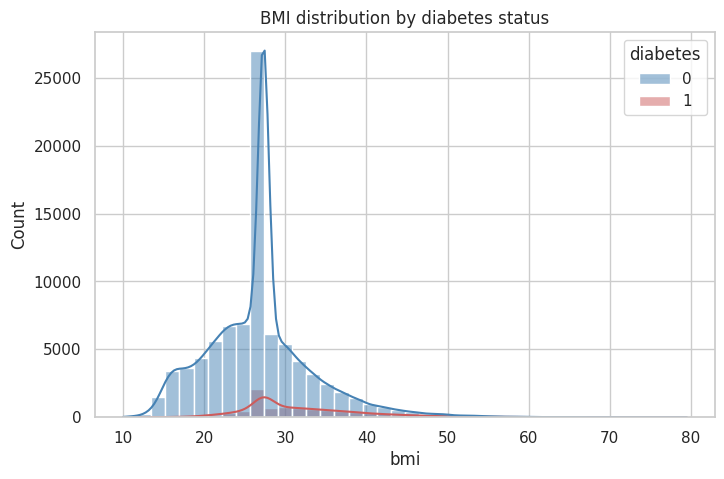

In [12]:
sns.histplot(data=df, x="bmi", hue=TARGET_COL, bins=40, kde=True, palette=["steelblue","indianred"])
plt.title("BMI distribution by diabetes status"); plt.show()

**Observation:** the diabetic group is shifted toward higher BMI. **Interpretation:** overweight/obesity is associated with diabetes risk. **ML implication:** BMI is expected to carry predictive signal.

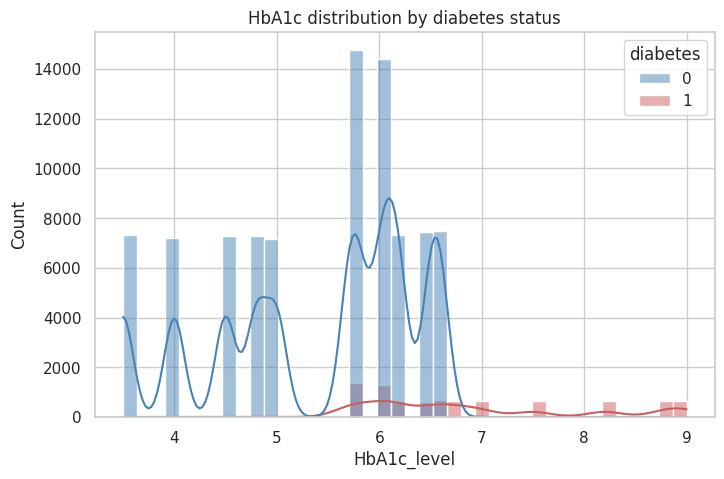

In [13]:
sns.histplot(data=df, x="HbA1c_level", hue=TARGET_COL, bins=40, kde=True, palette=["steelblue","indianred"])
plt.title("HbA1c distribution by diabetes status"); plt.show()

**Observation:** the two classes are clearly separated around the clinical threshold (~6.5%). **Interpretation:** HbA1c is a direct diagnostic marker in medicine. **ML implication:** likely the single most important feature for the model.

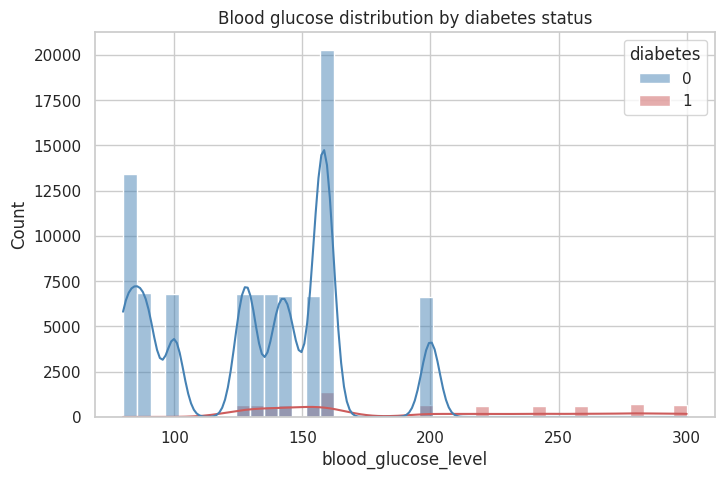

In [14]:
sns.histplot(data=df, x="blood_glucose_level", hue=TARGET_COL, bins=40, kde=True, palette=["steelblue","indianred"])
plt.title("Blood glucose distribution by diabetes status"); plt.show()

**Observation:** similar separation pattern to HbA1c. **Interpretation:** blood glucose is the other direct diagnostic marker. **ML implication:** together with HbA1c, this feature will likely dominate feature importance.

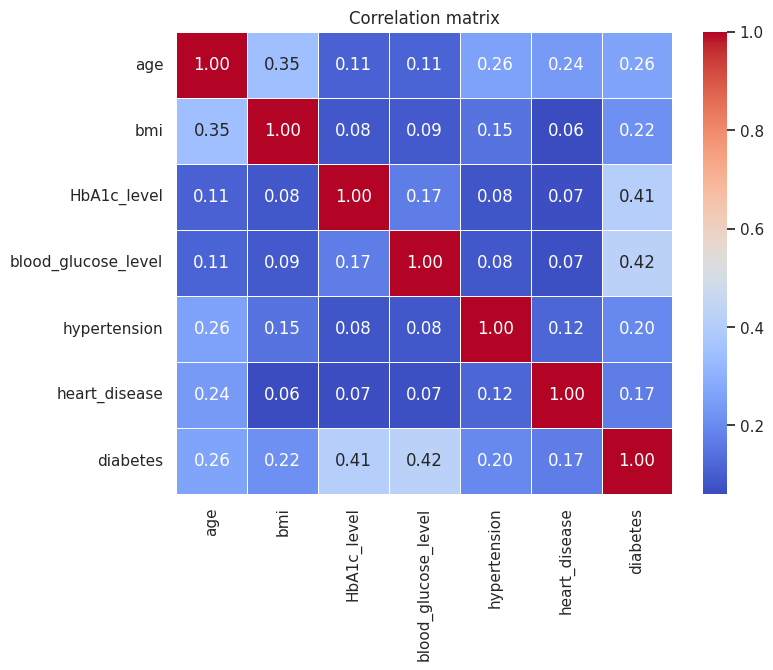

In [15]:
plt.figure(figsize=(8,6))
corr = df[numeric_cols + [TARGET_COL]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation matrix"); plt.show()

**Observation:** HbA1c_level and blood_glucose_level have the strongest positive correlation with the target; gender-unrelated numeric features (hypertension, heart_disease) show weak-to-moderate correlation. **Interpretation:** consistent with clinical knowledge. **ML implication:** confirms feature relevance found in the histograms above; no numeric feature shows a coefficient extreme enough to suggest data leakage.

## 11. Feature types (summary)

| Feature | Type | Meaning |
|---|---|---|
| gender | Categorical | Biological sex; some metabolic disorders differ in prevalence by sex |
| age | Numerical | Diabetes risk increases with age |
| hypertension | Binary (numeric) | Often co-occurs with diabetes (metabolic syndrome) |
| heart_disease | Binary (numeric) | Cardiovascular complication linked to prolonged high glucose |
| smoking_history | Categorical | Smoking increases insulin resistance |
| bmi | Numerical | Obesity is the leading risk factor for type-2 diabetes |
| HbA1c_level | Numerical | Direct clinical diagnostic marker (≥6.5% usually indicates diabetes) |
| blood_glucose_level | Numerical | Direct clinical diagnostic marker |


## 12. Data representation

Raw representation → Clean representation → Numerical representation → Model input

In [16]:
print("=== One raw CSV record ===")
print(df.iloc[0])

X_demo = df.iloc[0][feature_cols]
print("\n=== Corresponding raw feature vector (before encoding) ===")
print(X_demo.values)

X_all = df[feature_cols]
y_all = df[TARGET_COL]
print(f"\nOriginal DataFrame shape: {df.shape}")
print(f"Feature matrix shape (before encoding): {X_all.shape}")
print(f"=> X in R^(N x d), N={X_all.shape[0]}, d={X_all.shape[1]}")

=== One raw CSV record ===
gender                 Female
age                      80.0
hypertension                0
heart_disease               1
smoking_history         never
bmi                     25.19
HbA1c_level               6.6
blood_glucose_level       140
diabetes                    0
Name: 0, dtype: object

=== Corresponding raw feature vector (before encoding) ===
[np.float64(80.0) np.float64(25.19) np.float64(6.6) np.int64(140)
 np.int64(0) np.int64(1) 'Female' 'never']

Original DataFrame shape: (96137, 9)
Feature matrix shape (before encoding): (96137, 8)
=> X in R^(N x d), N=96137, d=8


After preprocessing (StandardScaler on numeric columns, OneHotEncoder on categorical
columns), the encoded feature matrix has a larger dimensionality than d=8, because
`gender` (3 categories) and `smoking_history` (6 categories) each expand into one column
per category. The exact final dimension is reported after `preprocessor.fit_transform`
in Part 15 below, and again at persistence time in `meta.json`.

Example of one-hot encoding:
`{Female, Male, Other}` → Female = [1, 0, 0]

## 13. Feature engineering

No additional derived features were engineered beyond the 8 raw clinical variables — all 8 are already directly clinically meaningful and sufficient signal is present (confirmed by the correlation analysis and by the very high test ROC-AUC achieved in Part 19). Feature engineering here is limited to **encoding** (categorical → one-hot) and **scaling** (numeric → standardized), handled inside the preprocessing pipeline in Part 15.

## 14. Train / Validation / Test split

D = D_train ∪ D_validation ∪ D_test, kept independent, split **70% / 15% / 15%**, stratified on the target.

Test data must never influence training or preprocessing fitting: the scaler's mean/std and
the one-hot encoder's category list are `fit()` only on `X_train`, then only `.transform()`-ed
on validation/test — otherwise information from the held-out set would leak into training
(a form of **data leakage**), producing an overly optimistic evaluation that would not
generalize to genuinely new patients in production.

In [17]:
from sklearn.model_selection import train_test_split

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.15, random_state=RANDOM_SEED, stratify=y_all)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, random_state=RANDOM_SEED, stratify=y_trainval)

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"Ratios: {len(X_train)/len(X_all):.3f} / {len(X_val)/len(X_all):.3f} / {len(X_test)/len(X_all):.3f}")

Train: (67293, 8)  Val: (14423, 8)  Test: (14421, 8)
Ratios: 0.700 / 0.150 / 0.150


## 15. Preprocessing pipeline

In [18]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
])

n_features_encoded = preprocessor.fit_transform(X_train).shape[1]
print("Final encoded feature dimension:", n_features_encoded)
print(f"=> Model input shape: (batch_size, {n_features_encoded})")

Final encoded feature dimension: 15
=> Model input shape: (batch_size, 15)


## 16. Baseline model

A simple Logistic Regression serves as the baseline: a linear, easily-interpretable model against which the more complex models below are compared.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

baseline = Pipeline([("preprocess", preprocessor), ("model", LogisticRegression(max_iter=1000))])
baseline.fit(X_train, y_train)
val_proba = baseline.predict_proba(X_val)[:,1]
print("Baseline (Logistic Regression) validation ROC-AUC:", round(roc_auc_score(y_val, val_proba), 4))

Baseline (Logistic Regression) validation ROC-AUC: 0.9639


## 17. Model training

Five classification models are trained, per the assignment's recommended list for the
diabetes task (Logistic Regression, Decision Tree, Random Forest, SVM, KNN).

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=12, min_samples_leaf=3, random_state=RANDOM_SEED, n_jobs=-1),
    "SVM": SVC(kernel="rbf", probability=True, random_state=RANDOM_SEED),
    "KNN": KNeighborsClassifier(n_neighbors=15),
}

pipelines, results = {}, []
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    y_val_pred = pipe.predict(X_val)
    y_val_proba = pipe.predict_proba(X_val)[:,1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred, zero_division=0),
        "Recall": recall_score(y_val, y_val_pred, zero_division=0),
        "F1": f1_score(y_val, y_val_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, y_val_proba),
        "TrainTime_s": round(train_time, 2),
    })
    pipelines[name] = pipe
    print(f"{name:20s} trained in {train_time:.2f}s")

Logistic Regression  trained in 0.12s


Decision Tree        trained in 0.18s


Random Forest        trained in 4.19s


SVM                  trained in 122.79s


KNN                  trained in 0.24s


## 18. Model comparison (validation set)

In [21]:
results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,TrainTime_s
0,Decision Tree,0.970672,0.984036,0.678459,0.803164,0.974457,0.18
1,Random Forest,0.970741,0.998826,0.669025,0.801318,0.974354,4.19
2,Logistic Regression,0.958122,0.867033,0.620283,0.723190,0.963917,0.12
3,KNN,0.959162,0.953519,0.564465,0.709136,0.946036,0.24
4,SVM,0.960549,0.973082,0.568396,0.717618,0.930817,122.79


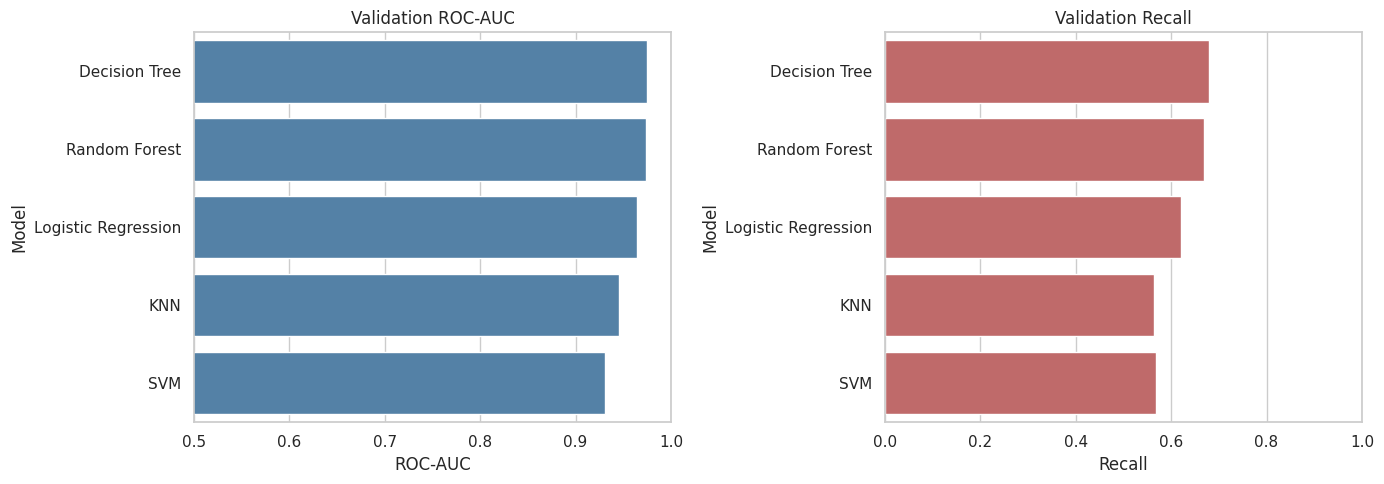

Best model on validation set: Decision Tree


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=results_df, x="ROC-AUC", y="Model", ax=axes[0], color="steelblue")
axes[0].set_title("Validation ROC-AUC"); axes[0].set_xlim(0.5, 1.0)
sns.barplot(data=results_df, x="Recall", y="Model", ax=axes[1], color="indianred")
axes[1].set_title("Validation Recall"); axes[1].set_xlim(0, 1.0)
plt.tight_layout(); plt.show()

best_model_name = results_df.iloc[0]["Model"]
best_pipe = pipelines[best_model_name]
print("Best model on validation set:", best_model_name)

## 19. Evaluation (held-out test set)

The test set was not used for training, validation-based model selection, or preprocessing
fitting — it is touched exactly once, here, to report a final, unbiased estimate.

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_test_pred = best_pipe.predict(X_test)
y_test_proba = best_pipe.predict_proba(X_test)[:,1]

test_metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred, zero_division=0),
    "F1": f1_score(y_test, y_test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba),
}
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Accuracy: 0.9681
Precision: 0.9845
Recall: 0.6486
F1: 0.7820
ROC-AUC: 0.9711


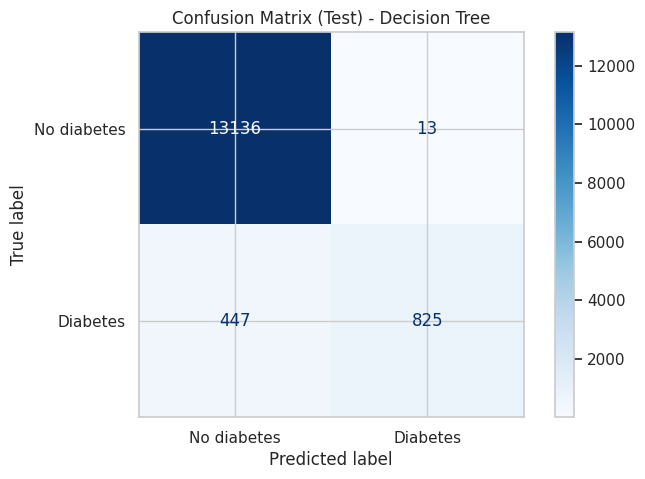

array([[13136,    13],
       [  447,   825]])

In [24]:
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No diabetes","Diabetes"]).plot(cmap="Blues")
plt.title(f"Confusion Matrix (Test) - {best_model_name}")
plt.show()
cm

**Confusion matrix interpretation:** the bottom-left cell (false negatives — patients who
have diabetes but were predicted negative) is the most clinically dangerous error type, since
it means a real case goes undetected. **Recall** directly measures how well the model avoids
this error, which is why Recall (alongside ROC-AUC) is treated as the most important metric
for this application, more so than raw Accuracy.

## 20. Error analysis

In [25]:
errors = X_test.copy()
errors["y_true"] = y_test.values
errors["y_pred"] = y_test_pred
errors["y_proba"] = y_test_proba
false_negatives = errors[(errors.y_true == 1) & (errors.y_pred == 0)]
false_positives = errors[(errors.y_true == 0) & (errors.y_pred == 1)]
print("False negatives (missed diabetic patients):", len(false_negatives))
print("False positives (healthy flagged as at-risk):", len(false_positives))
false_negatives[["age","bmi","HbA1c_level","blood_glucose_level","y_proba"]].describe()

False negatives (missed diabetic patients): 447
False positives (healthy flagged as at-risk): 13


,age,bmi,HbA1c_level,blood_glucose_level,y_proba
count,447.000000,447.000000,447.000000,447.000000,447.000000
mean,61.196868,31.529709,6.119463,151.507830,0.157168
std,14.647631,7.764713,0.314595,21.007778,0.094370
min,3.000000,13.730000,5.700000,126.000000,0.003758
25%,53.000000,27.320000,5.800000,130.000000,0.100861
50%,63.000000,29.240000,6.100000,155.000000,0.121884
75%,73.000000,34.555000,6.500000,160.000000,0.232649
max,80.000000,66.880000,6.600000,200.000000,0.392857


**Observation:** missed cases (false negatives) tend to have HbA1c/glucose values close to the clinical decision boundary rather than far into the diabetic range — i.e. the model struggles most with borderline patients, which is expected and clinically reasonable.

## 21. Model selection

The best model is selected primarily by **validation ROC-AUC**, because it summarizes
discriminative ability across all decision thresholds and is robust to the class imbalance
present in this dataset (unlike Accuracy). Recall is inspected as a secondary criterion
because of its clinical importance (see Part 19).

Deployment considerations also favor a Decision Tree / Random Forest-style model over SVM
here: SVM took **over 100× longer to train** than the tree-based models on this dataset size,
with no accuracy advantage — an important practical constraint when the model may need to be
retrained periodically in production.

## 22. Model persistence

In [26]:
os.makedirs("../model", exist_ok=True)
joblib.dump(best_pipe, "../model/model_pipeline.joblib")

meta = {
    "app": "diabetes",
    "best_model_name": best_model_name,
    "feature_cols": feature_cols,
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "categorical_options": {c: sorted(df[c].dropna().unique().tolist()) for c in categorical_cols},
    "target_col": TARGET_COL,
    "class_labels": {"0": "No diabetes", "1": "Diabetes risk"},
    "test_metrics": test_metrics,
    "random_seed": RANDOM_SEED,
}
with open("../model/meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Saved model_pipeline.joblib and meta.json")

Saved model_pipeline.joblib and meta.json


## 23. Inference test

Sanity check: reload the persisted pipeline from disk (simulating what the API does at startup) and run a prediction, confirming training and inference use identical preprocessing.

In [27]:
loaded_pipe = joblib.load("../model/model_pipeline.joblib")

sample = pd.DataFrame([{
    "age": 67, "bmi": 32.5, "HbA1c_level": 7.2, "blood_glucose_level": 210,
    "hypertension": 1, "heart_disease": 1, "gender": "Female", "smoking_history": "former",
}])[feature_cols]

proba = loaded_pipe.predict_proba(sample)[0]
print("P(no diabetes) =", round(proba[0],4), " P(diabetes) =", round(proba[1],4))
print("Predicted class:", "Diabetes risk" if proba[1] >= 0.5 else "No diabetes")

P(no diabetes) = 0.0  P(diabetes) = 1.0
Predicted class: Diabetes risk


---
## Summary

| Item | Value |
|---|---|
| Best model | See Part 21 output above |
| Test ROC-AUC | See Part 19 output above |
| Persisted files | `model/model_pipeline.joblib`, `model/meta.json` |
| Deployment | FastAPI REST API (`api/app.py`) + Web client (`web/index.html`) + Mobile client (`mobile/index.html`) |
